# 07a — Plots mémoire (figures finales)

Figures publication-ready pour le mémoire (format PLoS One, rendu 15/06/2026).

**Participant exemple** : `012WaCh` (3 essais complets 420s, signal propre, 0 spike)

**Figures** :
1. Pipeline preprocessing (5 étapes : raw → despike → EMD → Butterworth → décimé)
2. Sand detection (vue XY, 3 conditions)
3. TDE parameters (AMI + FNN)
4. Torus 3D simpliste (trajectoire + ellipsoïde 2σ)
5. Signaux résilience temporels (sig_var + sig_radius pendant pert)
6. Résultats stats (clean du 06)
7. Heatmap participant × condition

Tous les outputs : `outputs/figures/fig{N}_*.png` en DPI 150 (qualité publication).

In [1]:
from resilience import paths, participants, config
from resilience.io import loader, writer
from resilience.processing import preprocess, detection, tde
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon, Rectangle
from matplotlib.lines import Line2D
from mpl_toolkits.mplot3d import Axes3D  # noqa
from scipy.signal import welch
from pathlib import Path
%matplotlib inline

# Style publication
plt.rcParams.update({
    'font.size': 10,
    'axes.titlesize': 11,
    'axes.labelsize': 10,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
    'legend.fontsize': 8,
    'figure.dpi': 100,
    'savefig.dpi': 150,
    'savefig.bbox': 'tight',
})

FIG_DIR = Path(paths.OUTPUTS_DIR) / 'figures'
FIG_DIR.mkdir(parents=True, exist_ok=True)

# Constantes
EXAMPLE_P = '012WaCh'
EXAMPLE_COND = 'silence'

COND_ORDER = ['silence', 'tempo_random', 'beatmove_adaptatif']
COND_LABELS = {'silence': 'Silence', 'tempo_random': 'Tempo random', 'beatmove_adaptatif': 'BeatMove'}
COND_COLORS = {'silence': '#4C72B0', 'tempo_random': '#DD8452', 'beatmove_adaptatif': '#55A868'}

print(f"✅ Setup, figures → {FIG_DIR}")

✅ Setup, figures → C:\Users\etulyon1\Desktop\MASTER_IEAP\INTERNSHIP\Stage_M1_2026\outputs\figures


## Fig 1 — Pipeline preprocessing

5 étapes : raw → despike → EMD → Butterworth → décimé. Zoom 30s pour voir les structures fines.

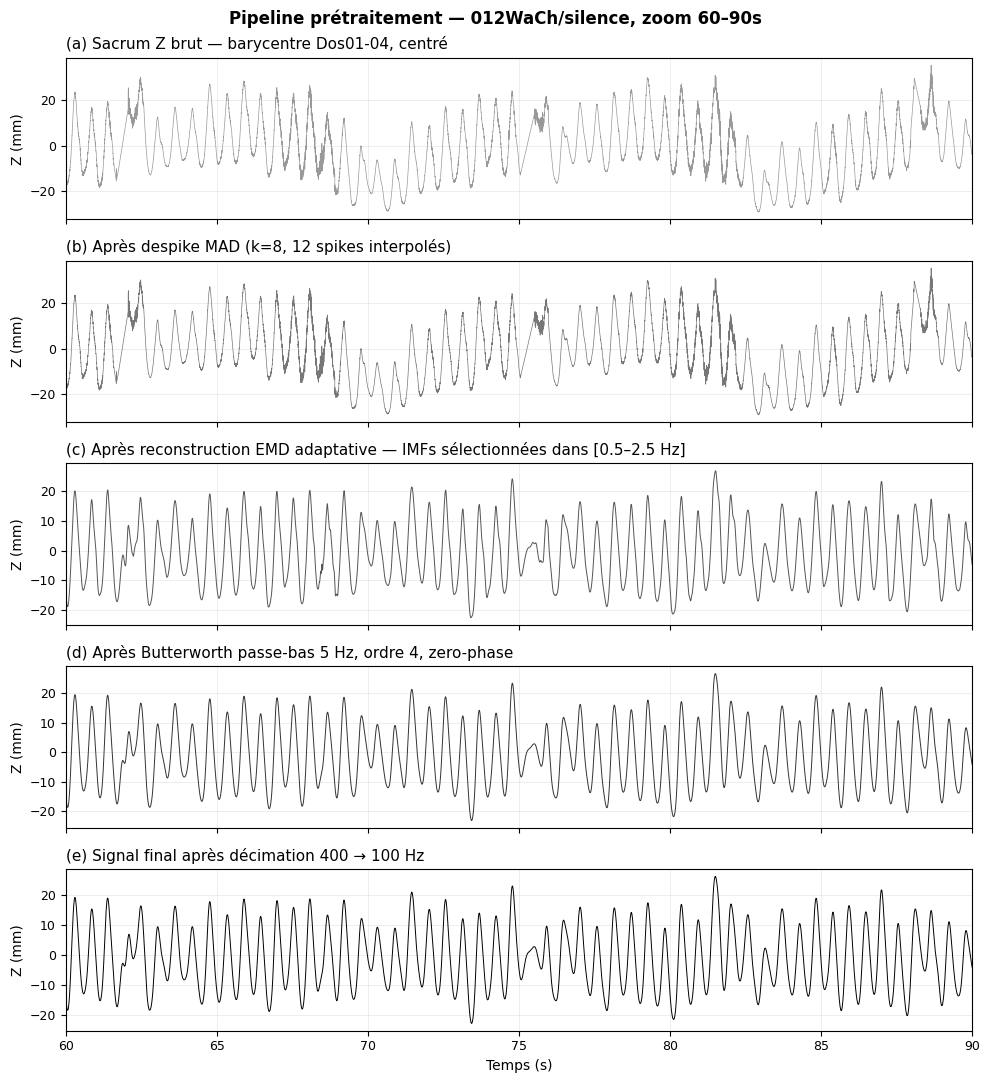

In [2]:
# Re-lancer le preprocess complet sur l'essai exemple pour avoir toutes les étapes intermédiaires
raw_path = paths.raw_file(EXAMPLE_P, EXAMPLE_COND)
data, fmt = loader.load_mat(raw_path)
trajectories = loader.extract_marker_trajectories(data, fmt)

trial = participants.get_trial(EXAMPLE_P, EXAMPLE_COND)
n_before = next(iter(trajectories.values())).shape[0]
i_start = int(trial.crop_start_s * config.FS_RAW) if trial.crop_start_s else 0
i_end   = int(trial.crop_end_s * config.FS_RAW) if trial.crop_end_s else n_before
trajectories = {m: xyz[i_start:i_end] for m, xyz in trajectories.items()}

out = preprocess.run(trajectories, axis='Z', apply_despike=True,
                      despike_k=8.0, verbose=False)

fs_raw   = config.FS_RAW
fs_clean = config.FS_CLEAN
t_raw   = np.arange(len(out['sacrum_axis_raw'])) / fs_raw
t_clean = out['time_final']

# Zoom sur 60-90s pour bien voir les structures de marche
z0, z1 = 60.0, 90.0
mask_raw = (t_raw >= z0) & (t_raw <= z1)
mask_clean = (t_clean >= z0) & (t_clean <= z1)

fig, axes = plt.subplots(5, 1, figsize=(10, 11), sharex=True)

axes[0].plot(t_raw[mask_raw], out['sacrum_axis_raw'][mask_raw],
              color='#999', linewidth=0.5)
axes[0].set_title('(a) Sacrum Z brut — barycentre Dos01-04, centré', loc='left')
axes[0].set_ylabel('Z (mm)')

axes[1].plot(t_raw[mask_raw], out['sacrum_despiked'][mask_raw],
              color='#777', linewidth=0.5)
n_spikes = out['despike_stats']['n_spikes']
axes[1].set_title(f'(b) Après despike MAD (k=8, {n_spikes} spikes interpolés)', loc='left')
axes[1].set_ylabel('Z (mm)')

axes[2].plot(t_raw[mask_raw], out['sacrum_emd'][mask_raw],
              color='#555', linewidth=0.7)
axes[2].set_title(f'(c) Après reconstruction EMD adaptative — IMFs sélectionnées dans [0.5–2.5 Hz]', loc='left')
axes[2].set_ylabel('Z (mm)')

axes[3].plot(t_raw[mask_raw], out['sacrum_filt'][mask_raw],
              color='#333', linewidth=0.7)
axes[3].set_title('(d) Après Butterworth passe-bas 5 Hz, ordre 4, zero-phase', loc='left')
axes[3].set_ylabel('Z (mm)')

axes[4].plot(t_clean[mask_clean], out['signal_final'][mask_clean],
              color='#000', linewidth=0.7)
axes[4].set_title(f'(e) Signal final après décimation 400 → 100 Hz', loc='left')
axes[4].set_ylabel('Z (mm)')
axes[4].set_xlabel('Temps (s)')

for ax in axes:
    ax.grid(alpha=0.3, linewidth=0.5)
    ax.set_xlim(z0, z1)

plt.suptitle(f'Pipeline prétraitement — {EXAMPLE_P}/{EXAMPLE_COND}, zoom {z0:.0f}–{z1:.0f}s',
              fontweight='bold')
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig1_pipeline_preprocessing.png')
plt.show()

## Fig 2 — Sand detection (vue XY, 3 conditions)

Trajectoire sacrum + bac sable + points oranges (in bbox) pour les 3 conditions du participant exemple.

C:\Users\etulyon1\AppData\Local\Temp\ipykernel_11432\728140394.py:4: RuntimeWarning: Mean of empty slice
  sacrum_xy = np.nanmean(dos_xy, axis=0)


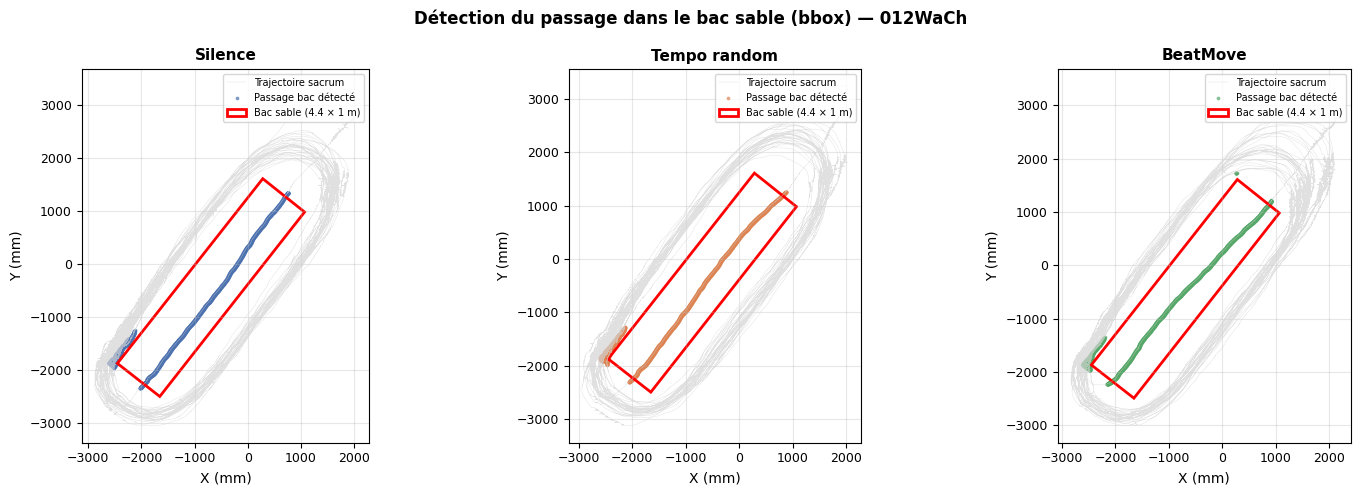

In [3]:
def load_sacrum_xy_and_detect(code, cond):
    d = writer.load_processed(code, cond)
    dos_xy = np.stack([d[f'raw_Dos{i:02d}'][:, :2] for i in range(1, 5)], axis=0)
    sacrum_xy = np.nanmean(dos_xy, axis=0)
    for ax in range(2):
        col = sacrum_xy[:, ax]
        if np.isnan(col).any():
            idx = np.arange(len(col))
            valid = ~np.isnan(col)
            if valid.sum() >= 2:
                col[~valid] = np.interp(idx[~valid], idx[valid], col[valid])
            sacrum_xy[:, ax] = col
    det = detection.detect_sand_by_bbox(sacrum_xy)
    return sacrum_xy, det

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
C = config.BAC_SAND_CORNERS_MM

for ax, cond in zip(axes, COND_ORDER):
    xy, det = load_sacrum_xy_and_detect(EXAMPLE_P, cond)
    in_bbox = det['in_bbox']

    ax.plot(xy[:, 0], xy[:, 1], color='lightgray', linewidth=0.3, alpha=0.7, label='Trajectoire sacrum')
    if in_bbox.any():
        ax.scatter(xy[in_bbox, 0], xy[in_bbox, 1], s=3, color=COND_COLORS[cond],
                    alpha=0.6, label='Passage bac détecté')

    rect = Polygon([C['A'], C['B'], C['C'], C['D']],
                    closed=True, fill=False, edgecolor='red', linewidth=2, label='Bac sable (4.4 × 1 m)')
    ax.add_patch(rect)

    ax.set_aspect('equal')
    ax.set_title(COND_LABELS[cond], fontweight='bold')
    ax.set_xlabel('X (mm)')
    ax.set_ylabel('Y (mm)')
    ax.legend(loc='upper right', fontsize=7)
    ax.grid(alpha=0.3)

plt.suptitle(f'Détection du passage dans le bac sable (bbox) — {EXAMPLE_P}',
              fontweight='bold')
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig2_sand_detection.png')
plt.show()

## Fig 3 — TDE parameters (AMI + FNN, 1 participant)

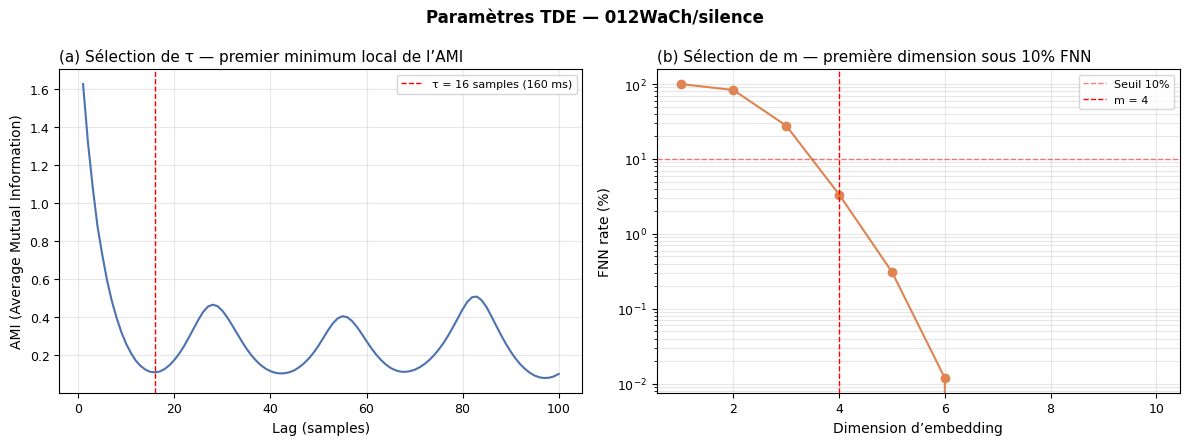


τ = 16 samples = 160 ms
m = 4


In [4]:
# Charger signal de l'essai exemple
d = writer.load_processed(EXAMPLE_P, EXAMPLE_COND)
sig = d['signal_final'].astype(float)

# AMI
tau, ami_values = tde.compute_ami(sig, max_lag=100)
# FNN avec params 10% / r=15 (Mehdizadeh 2020)
m, fnn_rates = tde.compute_fnn(sig, max_dim=10, tau=tau, threshold=10.0, r_threshold=15.0)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].plot(range(1, len(ami_values)+1), ami_values, color='#4C72B0', linewidth=1.5)
axes[0].axvline(tau, color='red', linestyle='--', linewidth=1, label=f'τ = {tau} samples ({tau/100*1000:.0f} ms)')
axes[0].set_xlabel('Lag (samples)')
axes[0].set_ylabel('AMI (Average Mutual Information)')
axes[0].set_title('(a) Sélection de τ — premier minimum local de l’AMI', loc='left')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].semilogy(range(1, len(fnn_rates)+1), fnn_rates, '-o', color='#DD8452',
                  linewidth=1.5, markersize=6)
axes[1].axhline(10, color='red', linestyle='--', linewidth=1, alpha=0.5, label='Seuil 10%')
axes[1].axvline(m, color='red', linestyle='--', linewidth=1, label=f'm = {m}')
axes[1].set_xlabel('Dimension d’embedding')
axes[1].set_ylabel('FNN rate (%)')
axes[1].set_title('(b) Sélection de m — première dimension sous 10% FNN', loc='left')
axes[1].legend()
axes[1].grid(alpha=0.3, which='both')

plt.suptitle(f'Paramètres TDE — {EXAMPLE_P}/{EXAMPLE_COND}', fontweight='bold')
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig3_tde_parameters.png')
plt.show()

print(f"\nτ = {tau} samples = {tau*10} ms")
print(f"m = {m}")

## Fig 4 — Torus 3D simpliste (trajectoire + ellipsoïde 2σ)

3 sub-plots (silence / tempo / beatmove), même participant. Projection (X[t], X[t+τ], X[t+2τ]). 
Trajectoire colorée : **gris** = baseline, **rouge** = perturbation. Ellipsoïde 2σ en orange transparent.

C:\Users\etulyon1\AppData\Local\Temp\ipykernel_11432\2753105536.py:41: RuntimeWarning: Mean of empty slice
  sac_xy = np.nanmean(dos_xy, axis=0)


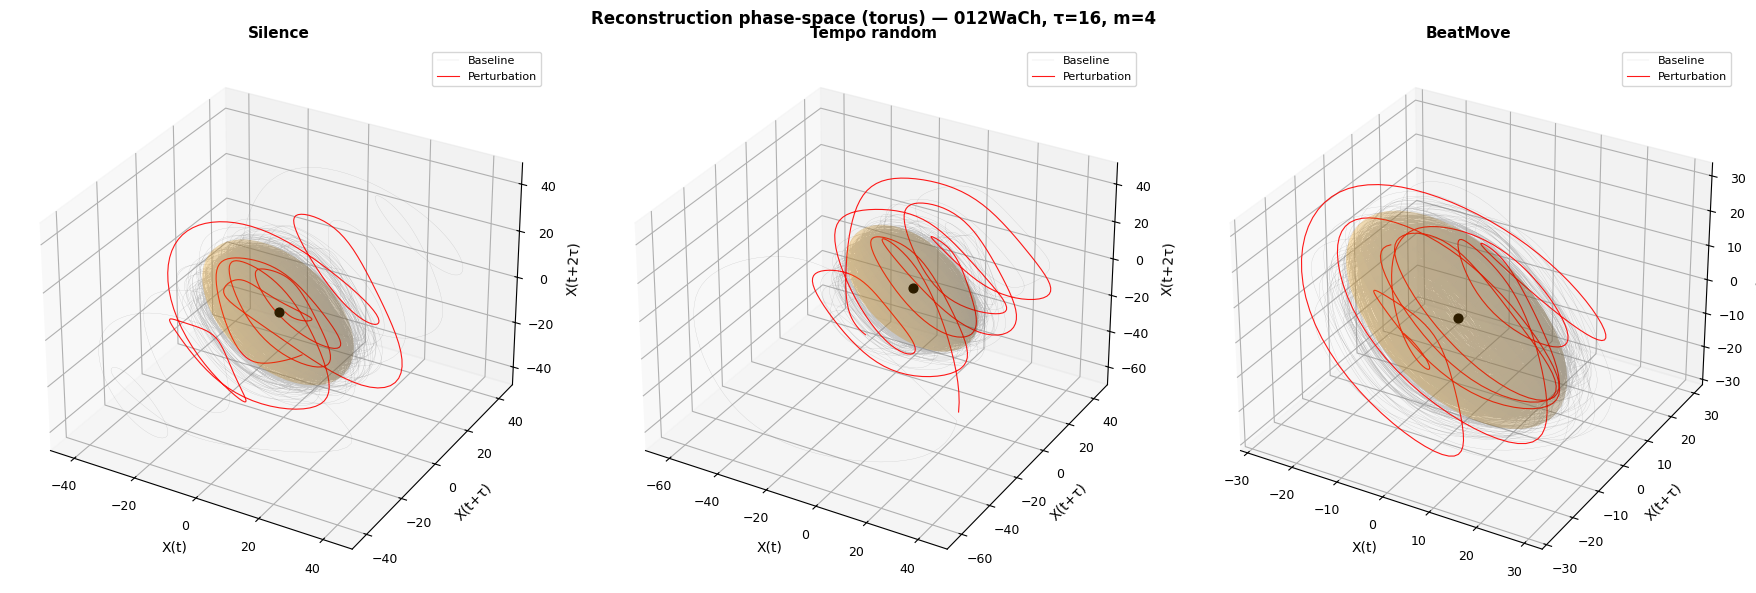

In [5]:
def compute_ellipsoid_2sigma(points, n_pts=30):
    """Calcule un ellipsoïde 2σ autour du centroïde via matrice de covariance."""
    centroid = points.mean(axis=0)
    cov = np.cov(points.T)
    eigvals, eigvecs = np.linalg.eigh(cov)
    # 2σ = facteur 2 sur sqrt(eigenvalues)
    radii = 2 * np.sqrt(eigvals)

    # Sphere unitaire en paramétrique
    u = np.linspace(0, 2*np.pi, n_pts)
    v = np.linspace(0, np.pi, n_pts)
    x = np.outer(np.cos(u), np.sin(v))
    y = np.outer(np.sin(u), np.sin(v))
    z = np.outer(np.ones_like(u), np.cos(v))

    # Scale par radii, rotate par eigvecs, translate au centroid
    points_unit = np.stack([x.ravel(), y.ravel(), z.ravel()], axis=1)
    points_scaled = points_unit * radii
    points_rotated = points_scaled @ eigvecs.T
    points_final = points_rotated + centroid
    return (points_final[:, 0].reshape(n_pts, n_pts),
            points_final[:, 1].reshape(n_pts, n_pts),
            points_final[:, 2].reshape(n_pts, n_pts),
            centroid)


# Charger params TDE participant
df_tde = pd.read_csv(Path(paths.OUTPUTS_DIR) / 'tables' / '04_tde_per_participant.csv')
tau_p = int(df_tde[df_tde['participant'] == EXAMPLE_P]['tau_p'].iloc[0])
m_p   = int(df_tde[df_tde['participant'] == EXAMPLE_P]['m_p'].iloc[0])

fig = plt.figure(figsize=(18, 6))

for i, cond in enumerate(COND_ORDER):
    # Charger signal + détecter pert via bbox
    d = writer.load_processed(EXAMPLE_P, cond)
    sig = d['signal_final'].astype(float)
    t   = d['time_final'].astype(float)

    dos_xy = np.stack([d[f'raw_Dos{j:02d}'][:, :2] for j in range(1, 5)], axis=0)
    sac_xy = np.nanmean(dos_xy, axis=0)
    for ax_idx in range(2):
        col = sac_xy[:, ax_idx]
        if np.isnan(col).any():
            idx = np.arange(len(col))
            valid = ~np.isnan(col)
            if valid.sum() >= 2:
                col[~valid] = np.interp(idx[~valid], idx[valid], col[valid])
            sac_xy[:, ax_idx] = col
    det = detection.detect_sand_by_bbox(sac_xy)
    # Pert en référentiel post-crop (sacrum_xy = 400Hz → /FS_RAW)
    pert_entry = det['entry_t']
    pert_exit  = det['exit_t']

    # Reconstruction TDE
    XR = tde.phase_space_reconstruction(sig, tau=tau_p, dim=m_p)
    # Aligner les temps : XR perd (m-1)*tau frames au début
    pad = (m_p - 1) * tau_p
    t_xr = t[pad:pad + XR.shape[0]]

    # Masque pert dans XR
    pert_mask = (t_xr >= pert_entry) & (t_xr <= pert_exit)

    # Ellipsoïde sur baseline (hors pert)
    baseline_3d = XR[~pert_mask, :3]
    ex, ey, ez, centroid = compute_ellipsoid_2sigma(baseline_3d)

    ax = fig.add_subplot(1, 3, i+1, projection='3d')
    # Trajectoire baseline (gris fin)
    ax.plot(XR[~pert_mask, 0], XR[~pert_mask, 1], XR[~pert_mask, 2],
            color='gray', linewidth=0.2, alpha=0.4, label='Baseline')
    # Trajectoire pert (rouge épais)
    ax.plot(XR[pert_mask, 0], XR[pert_mask, 1], XR[pert_mask, 2],
            color='red', linewidth=0.8, alpha=0.9, label='Perturbation')
    # Centroïde
    ax.scatter(*centroid, color='black', s=40, zorder=5)
    # Ellipsoïde 2σ
    ax.plot_surface(ex, ey, ez, color='orange', alpha=0.15, edgecolor='none')

    ax.set_title(COND_LABELS[cond], fontweight='bold')
    ax.set_xlabel(f'X(t)')
    ax.set_ylabel(f'X(t+τ)')
    ax.set_zlabel(f'X(t+2τ)')
    ax.legend(fontsize=8, loc='upper right')

plt.suptitle(f'Reconstruction phase-space (torus) — {EXAMPLE_P}, τ={tau_p}, m={m_p}',
              fontweight='bold')
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig4_torus_3d_simple.png')
plt.show()

## Fig 5 — Signaux résilience temporels

sig_var et sig_radius pendant un essai, zone perturbation ombrée. Montre concrètement le "pic de stress" pendant la marche dans le sable.

C:\Users\etulyon1\AppData\Local\Temp\ipykernel_11432\4267864294.py:32: RuntimeWarning: Mean of empty slice
  sac_xy = np.nanmean(dos_xy, axis=0)


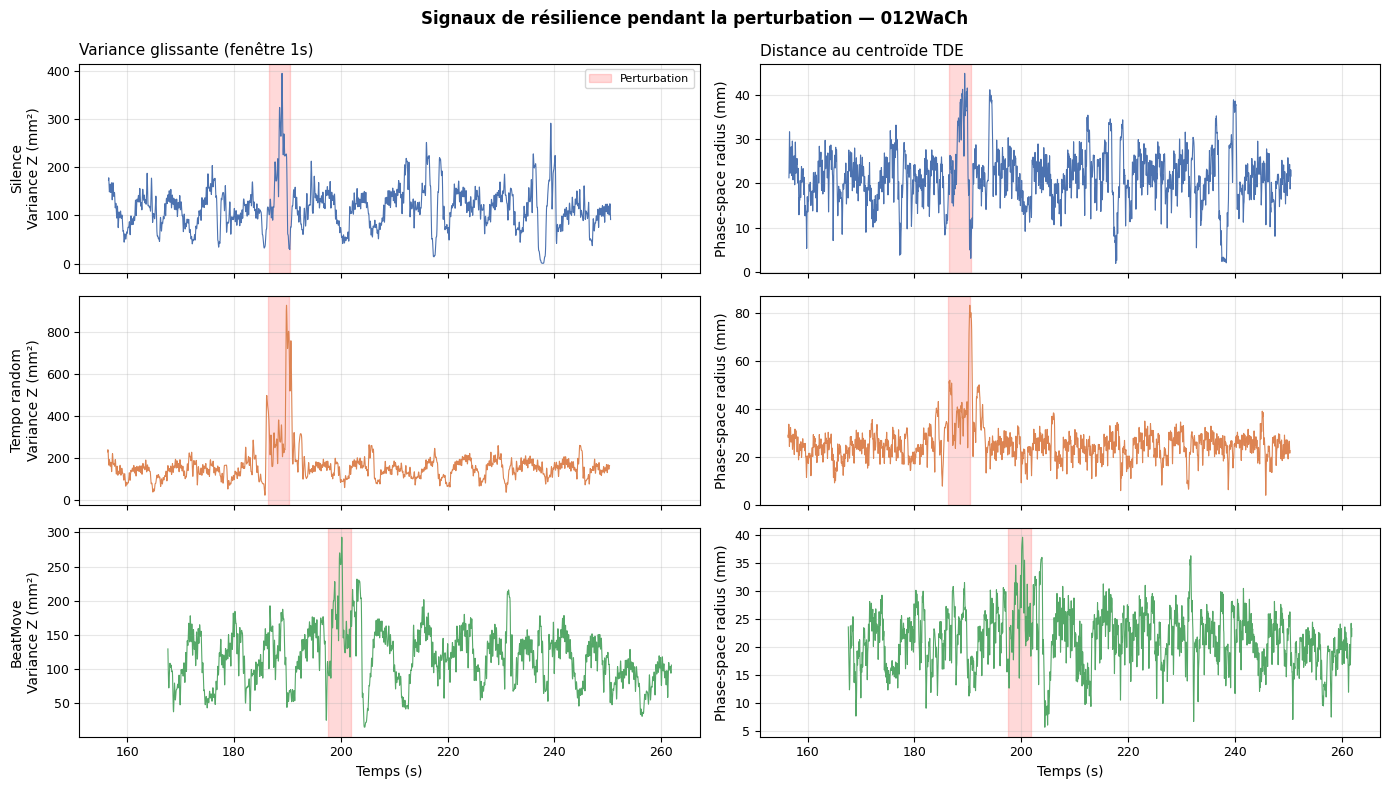

In [6]:
FS = config.FS_CLEAN

def compute_resilience_signals(signal_z, tau, m, fs=FS, win_s=1.0):
    n = len(signal_z)
    win = int(win_s * fs)
    half = win // 2

    # variance glissante
    sig_var = np.zeros(n)
    for i in range(n):
        i0, i1 = max(0, i - half), min(n, i + half)
        sig_var[i] = np.var(signal_z[i0:i1])

    # radius
    ps = tde.phase_space_reconstruction(signal_z, tau=tau, dim=m)
    centroid = ps.mean(axis=0)
    radius = np.linalg.norm(ps - centroid, axis=1)
    pad = (m - 1) * tau
    sig_radius = np.concatenate([np.full(pad, np.nan), radius])

    return sig_var, sig_radius


fig, axes = plt.subplots(3, 2, figsize=(14, 8), sharex='col')

for row, cond in enumerate(COND_ORDER):
    d = writer.load_processed(EXAMPLE_P, cond)
    sig = d['signal_final'].astype(float)
    t   = d['time_final'].astype(float)

    dos_xy = np.stack([d[f'raw_Dos{j:02d}'][:, :2] for j in range(1, 5)], axis=0)
    sac_xy = np.nanmean(dos_xy, axis=0)
    for ax_idx in range(2):
        col = sac_xy[:, ax_idx]
        if np.isnan(col).any():
            idx = np.arange(len(col))
            valid = ~np.isnan(col)
            if valid.sum() >= 2:
                col[~valid] = np.interp(idx[~valid], idx[valid], col[valid])
            sac_xy[:, ax_idx] = col
    det = detection.detect_sand_by_bbox(sac_xy)
    pert_entry = det['entry_t']
    pert_exit  = det['exit_t']

    sig_var, sig_radius = compute_resilience_signals(sig, tau=tau_p, m=m_p)

    # Zoom autour de la perturbation : pert_entry - 30s → pert_exit + 60s
    z0 = max(0, pert_entry - 30)
    z1 = min(t[-1], pert_exit + 60)
    msk = (t >= z0) & (t <= z1)

    axes[row, 0].plot(t[msk], sig_var[msk], color=COND_COLORS[cond], linewidth=0.8)
    axes[row, 0].axvspan(pert_entry, pert_exit, color='red', alpha=0.15, label='Perturbation')
    axes[row, 0].set_ylabel(f'{COND_LABELS[cond]}\nVariance Z (mm²)')
    axes[row, 0].grid(alpha=0.3)
    if row == 0:
        axes[row, 0].legend(loc='upper right')
        axes[row, 0].set_title('Variance glissante (fenêtre 1s)', loc='left')

    axes[row, 1].plot(t[msk], sig_radius[msk], color=COND_COLORS[cond], linewidth=0.8)
    axes[row, 1].axvspan(pert_entry, pert_exit, color='red', alpha=0.15)
    axes[row, 1].set_ylabel('Phase-space radius (mm)')
    axes[row, 1].grid(alpha=0.3)
    if row == 0:
        axes[row, 1].set_title('Distance au centroïde TDE', loc='left')

axes[2, 0].set_xlabel('Temps (s)')
axes[2, 1].set_xlabel('Temps (s)')

plt.suptitle(f'Signaux de résilience pendant la perturbation — {EXAMPLE_P}',
              fontweight='bold')
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig5_resilience_signals.png')
plt.show()

## Fig 6 — Résultats stats (clean)

Version propre du 06_stats_final, focus sur ratio_var + ratio_radius (les métriques significatives).

C:\Users\etulyon1\AppData\Local\Temp\ipykernel_11432\2859254221.py:18: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_by_cond, labels=[COND_LABELS[c] for c in COND_ORDER],
C:\Users\etulyon1\AppData\Local\Temp\ipykernel_11432\2859254221.py:18: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_by_cond, labels=[COND_LABELS[c] for c in COND_ORDER],


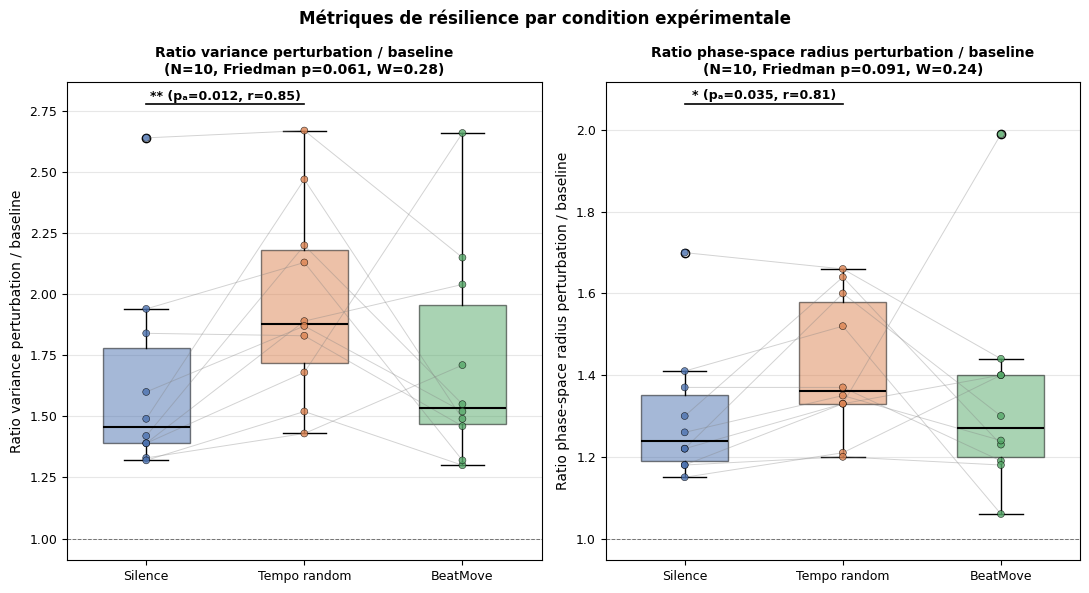

In [7]:
df_res  = pd.read_csv(Path(paths.OUTPUTS_DIR) / 'tables' / '05_resilience_metrics.csv')
df_fried = pd.read_csv(Path(paths.OUTPUTS_DIR) / 'tables' / '06_friedman.csv')
df_wilc  = pd.read_csv(Path(paths.OUTPUTS_DIR) / 'tables' / '06_wilcoxon_posthoc.csv')

# Garder seulement ratio_var et ratio_radius (les significatives)
metrics_fig6 = ['ratio_var', 'ratio_radius']
metrics_labels_fig6 = {
    'ratio_var':    'Ratio variance perturbation / baseline',
    'ratio_radius': 'Ratio phase-space radius perturbation / baseline',
}

fig, axes = plt.subplots(1, 2, figsize=(11, 6))

for ax, metric in zip(axes, metrics_fig6):
    pv = df_res.pivot(index='participant', columns='condition', values=metric).reindex(columns=COND_ORDER).dropna()
    data_by_cond = [pv[c].values for c in COND_ORDER]

    bp = ax.boxplot(data_by_cond, labels=[COND_LABELS[c] for c in COND_ORDER],
                     patch_artist=True, widths=0.55, medianprops={'color': 'black', 'linewidth': 1.5})
    for patch, c in zip(bp['boxes'], COND_ORDER):
        patch.set_facecolor(COND_COLORS[c])
        patch.set_alpha(0.5)

    # Lignes individuelles
    for p_code in pv.index:
        vals = pv.loc[p_code].values
        ax.plot([1, 2, 3], vals, '-', color='gray', alpha=0.35, linewidth=0.7)
        ax.scatter([1, 2, 3], vals, s=25, alpha=0.8,
                    c=[COND_COLORS[c] for c in COND_ORDER],
                    edgecolors='black', linewidths=0.4, zorder=5)

    ax.axhline(1, color='black', linestyle='--', linewidth=0.7, alpha=0.5)

    fried_row = df_fried[df_fried['metric'] == metric].iloc[0]
    title = f"{metrics_labels_fig6[metric]}\n(N={int(fried_row['N'])}, Friedman p={fried_row['p']:.3f}, W={fried_row['kendall_W']:.2f})"
    ax.set_title(title, fontweight='bold', fontsize=10)
    ax.set_ylabel(metrics_labels_fig6[metric])
    ax.grid(alpha=0.3, axis='y')

    # Annotations Wilcoxon sig
    sub = df_wilc[df_wilc['metric'] == metric]
    pair_x = {'sil vs tem': (1, 2), 'sil vs bea': (1, 3), 'tem vs bea': (2, 3)}
    y_top = max(np.concatenate(data_by_cond))
    y_range = y_top - min(np.concatenate(data_by_cond))
    y_offset = y_range * 0.08

    j_sig = 0
    for _, row in sub.iterrows():
        if row['sig_bonf'] != 'ns':
            x1, x2 = pair_x[row['pair']]
            y = y_top + y_offset * (1 + j_sig)
            ax.plot([x1, x2], [y, y], 'k-', linewidth=1.2)
            ax.text((x1 + x2)/2, y + y_offset*0.15,
                     f"{row['sig_bonf']} (pₐ={row['p_bonf']:.3f}, r={row['r']:.2f})",
                     ha='center', fontsize=9, fontweight='bold')
            j_sig += 1

plt.suptitle('Métriques de résilience par condition expérimentale',
              fontweight='bold', fontsize=12)
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig6_stats_clean.png')
plt.show()

## Fig 7 — Heatmap participant × condition

Visualisation individuelle des ratio_var par participant et condition.

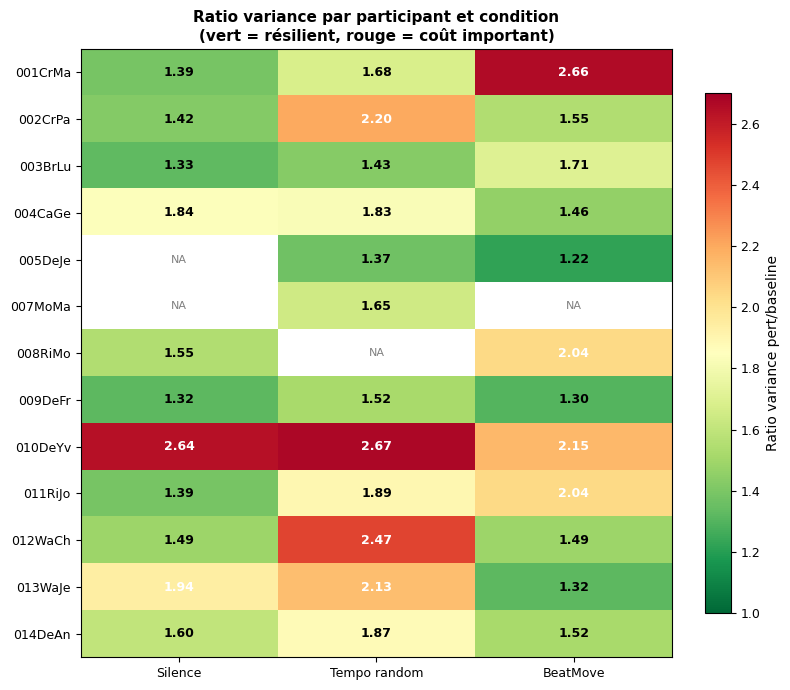

In [8]:
pv = df_res.pivot(index='participant', columns='condition', values='ratio_var').reindex(columns=COND_ORDER)

fig, ax = plt.subplots(figsize=(8, 7))
im = ax.imshow(pv.values, cmap='RdYlGn_r', aspect='auto', vmin=1.0, vmax=2.7)

# Annotations
for i in range(pv.shape[0]):
    for j in range(pv.shape[1]):
        v = pv.values[i, j]
        if not np.isnan(v):
            ax.text(j, i, f'{v:.2f}', ha='center', va='center',
                     color='black' if v < 1.9 else 'white', fontsize=9, fontweight='bold')
        else:
            ax.text(j, i, 'NA', ha='center', va='center', color='gray', fontsize=8)

ax.set_xticks(range(len(COND_ORDER)))
ax.set_xticklabels([COND_LABELS[c] for c in COND_ORDER])
ax.set_yticks(range(len(pv.index)))
ax.set_yticklabels(pv.index)

cbar = plt.colorbar(im, ax=ax, fraction=0.04)
cbar.set_label('Ratio variance pert/baseline', fontsize=10)

ax.set_title('Ratio variance par participant et condition\n(vert = résilient, rouge = coût important)',
              fontweight='bold')
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig7_heatmap_ratiovar.png')
plt.show()

## Récapitulatif

Toutes les figures sont sauvegardées dans `outputs/figures/` en DPI 150.

**Liste pour insertion dans le mémoire (PLoS One)** :
1. `fig1_pipeline_preprocessing.png` — Méthodes
2. `fig2_sand_detection.png` — Méthodes
3. `fig3_tde_parameters.png` — Méthodes
4. `fig4_torus_3d_simple.png` — Résultats (concept de résilience visualisé)
5. `fig5_resilience_signals.png` — Résultats (exemple temporel)
6. `fig6_stats_clean.png` — Résultats (figure principale)
7. `fig7_heatmap_ratiovar.png` — Résultats (hétérogénéité individuelle)

Prochaine étape : **Notebook 07b** — torus 3D interactif Plotly (version complète Antoine) pour la défense.